# RL3-Kontovrakis to Toubis
**Kontovrakis Konstantinos** | December 2025
[Link to Colab](https://colab.research.google.com/drive/1TrICMrasXFMw985GqmfLkWPHXkMZMYkP?usp=sharing)

## Dynamic Programming and Policy Iteration

Dynamic programming (DP) is a collection of algorithms used to compute optimal policies in environments with known dynamics and a Markov Decision Process (MDP) framework. In an MDP, we define:

* State space $S$  
* Action space $A$  
* Reward $R$  
* Dynamics $p(s', r \mid s, a)$ for all $s \in S$, $a \in A$, $r \in R$, and $s' \in S^+$

**Key idea:** Use value functions to organize and structure the search for good policies. Once the optimal value function is known, the optimal policy can be found by satisfying the Bellman Optimality Equations. DP algorithms turn these equations into update rules for iteratively improving approximations of value functions.

### Policy Evaluation

Policy evaluation aims to compute the state-value function $v_\pi$ for a given policy $\pi$.  
The exact value function satisfies:

$$v_\pi(s) = \sum_{a \in A} \pi(a \mid s) \sum_{s', r} p(s', r \mid s, a) \big[ r + \gamma v_\pi(s') \big], \quad \forall s \in S$$

For a known environment, this forms a set of $|S|$ linear equations in $|S|$ unknowns. In practice, we often approximate the value function iteratively:

$$v_0, v_1, v_2, \ldots$$

* Initial approximation $v_0$ can be chosen arbitrarily (terminal states set to 0).  
* Each iteration updates all states using the Bellman equation:

$$v_{k+1}(s) \leftarrow \sum_{a \in A} \pi(a \mid s) \sum_{s', r} p(s', r \mid s, a) \big[ r + \gamma v_k(s') \big]$$

The value function converges to $v_\pi$ as $k \to \infty$, assuming standard convergence conditions hold.

#### Expected Update

To update the value of a state $s$, we take the expected reward and next state values over all one-step transitions under the policy:

$$v(s) \gets \mathbb{E}[ R_{t+1} + \gamma v(S_{t+1}) \mid S_t = s ]$$

This is called an expected update, in contrast to sampling-based updates.  
In implementation, we can use either two arrays (old and new values) or a single array with in-place updates. Convergence is approximated: we stop when the maximum value change is below a threshold.

### Policy Improvement

Once a policy is evaluated, we can improve it by choosing the greedy action in each state:

$$\pi'(s) = \arg\max_a \sum_{s', r} p(s', r \mid s, a) \big[ r + \gamma v_\pi(s') \big]$$

If changing an action increases the value, we update the policy for that state. When the new policy $\pi'$ equals the old policy $\pi$, convergence is reached. By the Bellman Optimality Equations, this policy is optimal.

### Policy Iteration Algorithm

The Policy Iteration procedure alternates between policy evaluation and policy improvement until convergence:

1.  Evaluate the current policy $\pi$ to compute $v_\pi$.  
2.  Improve the policy by acting greedily with respect to $v_\pi$.  
3.  Repeat until the policy no longer changes.

---

## Jack's Car Rental
Our goal in this exercise is to solve the Jack's Car Rental problem (4.2 example in Sutton and Barto RL book), using the **Policy Iteration Method** defined above.

### Policy Evaluation and Improvement

We apply the iterative procedure to the specific dynamics of the car rental environment. Since the state space is finite, Policy Iteration is theoretically guaranteed to converge to an optimal policy in a finite number of iterations.

## Environment Dynamics

In the Jack's Car Rental example, the environment is fully known and satisfies the Markov property. 

The Policy Iteration algorithm requires us to compute:
1.  the transition probabilities $p(s' \mid s, a)$, and
2.  the expected reward $r(s, a)$

for every state $s$ and action $a$. 

### Daily Timeline and Calculation Flow

To implement the Bellman updates correctly, we must follow the specific chronology of events in the car rental problem. The process for a single time step $t$ is as follows:

1.  **End of day($S_t$):** The system is in state $s = (m, n)$, representing the number of cars at each location at the end of the day. We decide on an action $a$ (move cars).
2.  **Overnight (Action & Cost):** Cars are moved. 
    * The transfer cost $C(a) = 2 \times |a|$ is incurred immediately.
    * The number of cars available for the next day changes to:
        $$m' = m - a, \quad n' = n + a$$
        (bounded to $[0, 20]$).
3.  **Morning (Reward Generation):** The new day begins with $m'$ and $n'$ cars available.
    * Customers request cars based on the Poisson distribution.
    * Rewards are generated based on these *available* cars ($m', n'$), not the previous evening's count.
        $$R_{t+1} = \text{Expected Rentals}(m') \times 10 + \text{Expected Rentals}(n') \times 10$$
4.  **Daytime (Dynamics):** Cars are rented out and returned.
    * Rentals reduce the available stock.
    * Returns add to the stock (bounded by capacity).
5.  **Next Evening ($S_{t+1}$):** The day ends. The net change in cars results in the new state $s'$, determined by the transition probabilities $P(s' \mid s, a)$.

Thus, the value of a state-action pair is the immediate cost plus the expected reward from the *post-transfer* stock, plus the discounted value of the next evening's state.

### Environment Parameters

We initialize the environment according to the problem statement:

$$location\_sizes = [20, 20],\qquad \lambda^{\text{return}} = [3, 2],\qquad \lambda^{\text{request}} = [3, 4],$$

$$transfer\_cost = 2,\qquad transfer\_limit = 5,\qquad rental\_reward = 10.$$

These constants define the MDP dynamics. Each parking lot has Poisson rental requests and Poisson returns. Since rentals and returns occur independently at each lot, the two locations can be analyzed separately.

### Per-Location Transition Probabilities

For a location with $m$ cars at the beginning of the day (post-transfer), the number of rentals cannot exceed $m$. Rentals follow:

$$
\Pr(\text{rentals}=k) =
\begin{cases}
\text{Poisson}(k;\;\lambda^{\text{request}}), & 0 \le k < m, \\
1 - F_{\text{Poisson}}(m-1;\;\lambda^{\text{request}}), & k = m.
\end{cases}
$$

After $k$ rentals, the remaining cars are:
$$\text{remaining} = m - k.$$

Then returns occur. The number of returns is also Poisson-distributed, but capped because the parking lot has finite capacity:
$$
\Pr(\text{returns} = r) =
\begin{cases}
\text{Poisson}(r;\;\lambda^{\text{return}}), & 0 \le r < \text{cap}, \\
1 - F_{\text{Poisson}}(\text{cap}-1;\;\lambda^{\text{return}}), & r = \text{cap},
\end{cases}
$$
where
$$\text{cap} = \text{(maximum allowed returns before hitting capacity)} = \texttt{size} - \text{remaining}.$$

The final number of cars at the end of the day is:
$$n = \text{remaining} + \text{returns}.$$

Each parking lot is a Markov chain with transitions:
$$P_{m,n} = \sum_{k,r} \Pr(\text{rentals}=k)\Pr(\text{returns}=r) \cdot \text{Indicator} [n = m - k + r].$$

This is the probability function of the Problem that contains all the information about the environment dynamics.  

### Expected Rewards

At each location, the reward comes solely from rentals. If $k$ rentals occur and each rental yields reward $R$, then the expected reward at state $m$ is:

$$\mathbb{E}[R \mid m] = \sum_{k} k \cdot R \cdot \Pr(\text{rentals}=k).$$

In [1]:
# This routine executes policy iteration for the car rental problem of Exercise 4.2. The state (m,n) is the number
# of cars in the two locations, and the policy is the number of cars moved from the first location to the second one
#
# Input Parameters
# ================
# environment_parameters={
#     location_sizes[2]: a vector containing the sizes of the two locations
#     location_return_rates[2]: a vector containing the Poisson car return rates at the two locations
#     location_request_rates[2]: a vector containing the Poisson car request rates at the two locations
#     transfer_cost: the cost of transferring a car from one location to the other
#     transfer_limit: the maximum number of cars that can be transferred from one location to the other
#     rental_reward: the reward of a single rental
#     }
#
# policy_parameters={
#     gamma: the discount factor
#     evaluations_number: the number of policy evaluations in each policy iteration
#     iterations_number: the number of policy iterations that will be executed
#     initial_policy: the initial policy applied to all states.
#     }

import numpy as np
import scipy.stats

np.set_printoptions(precision=2, suppress=True)

# --- Environment parameters ---
environment_parameters = {
    "location_sizes": [20, 20],
    "location_return_rates": [3, 2],
    "location_request_rates": [3, 4],
    "transfer_cost": 2,
    "transfer_limit": 5,
    "rental_reward": 10
}

# --- Helper function to compute per-location transitions and rewards ---
def compute_location_transitions_and_rewards(size, lambda_return, lambda_request, rental_reward):
    P = np.zeros((size + 1, size + 1))             # P[m, n] = Prob(start m -> end n)
    reward_terms = np.zeros((size + 1, size + 1))  # reward component for each transition
    #I store what reward I get starting from m cars and ending with n cars
    for m in range(size + 1):
        for rentals in range(0, m + 1):
            # probability of this number of rentals / I use this loop here to calculate transition
            #probabilities for each possible number of rentals
            #We are not talking about the actual cars moving yet.
            #We are computing probabilities of transitions.
            #But those probabilities must respect physical limits (cars I have or I can receive).
            if rentals < m:
                p_rent = scipy.stats.poisson.pmf(rentals, lambda_request)
            #Else if rentals are equal to m or more (the rest of the distribution) then we give all
            #chance to rent all cars
            else:
                p_rent = 1.0 - scipy.stats.poisson.cdf(m - 1, lambda_request)

            remaining = m - rentals
            max_returns_bucket = size - remaining
            #Same for returns. If I have cars I give them, else I give the whole amount of cars.
            for ret in range(0, max_returns_bucket + 1):
                if ret < max_returns_bucket:
                    p_ret = scipy.stats.poisson.pmf(ret, lambda_return)
                else:
                    p_ret = 1.0 - scipy.stats.poisson.cdf(max_returns_bucket - 1, lambda_return)

                prob = p_rent * p_ret
                # final number of cars after rentals and returns
                final = remaining + ret
                if final > size:
                    final = size  # safety
                #Probability of going from m to final
                P[m, final] += prob
                reward_terms[m, final] += prob * (rentals * rental_reward)

    expected_rewards = np.sum(reward_terms, axis=1)
    return P, expected_rewards, reward_terms


# --- Compute per-location transitions ---
transition_probs1, expected_rewards1, expected_rewards_terms1 = compute_location_transitions_and_rewards(
    environment_parameters["location_sizes"][0],
    environment_parameters["location_return_rates"][0],
    environment_parameters["location_request_rates"][0],
    environment_parameters["rental_reward"]
)

transition_probs2, expected_rewards2, expected_rewards_terms2 = compute_location_transitions_and_rewards(
    environment_parameters["location_sizes"][1],
    environment_parameters["location_return_rates"][1],
    environment_parameters["location_request_rates"][1],
    environment_parameters["rental_reward"]
)

# --- Quick check ---
print("Row-sum check (loc 1):", np.min(np.sum(transition_probs1, axis=1)),
      np.max(np.sum(transition_probs1, axis=1)))
print("Row-sum check (loc 2):", np.min(np.sum(transition_probs2, axis=1)),
      np.max(np.sum(transition_probs2, axis=1)))

print("Expected rewards (loc 1, first 10 states):", expected_rewards1[:10])
print("Expected rewards (loc 2, first 10 states):", expected_rewards2[:10])

Row-sum check (loc 1): 0.9999999999999999 1.0000000000000004
Row-sum check (loc 2): 0.9999999999999998 1.0000000000000002
Expected rewards (loc 1, first 10 states): [ 0.    9.5  17.51 23.28 26.81 28.65 29.49 29.83 29.95 29.99]
Expected rewards (loc 2, first 10 states): [ 0.    9.82 18.9  26.52 32.19 35.9  38.05 39.15 39.66 39.88]


## Initialization of Policy and Value Function

#### Initial Policy
Initially we choose: 
$$\pi(m,n) = 0 \qquad \forall (m,n),$$
meaning no cars are moved in any state.

#### Initial Value Function
The value function is initialized to
$$V(m,n) = 0 \qquad \forall (m,n),$$
which is an arbitrary choice allowed in policy iteration. 

#### Expected Immediate Rewards
The expected immediate reward in a joint state is given by the sum of the expected rental rewards at each location. We pre-compute these values as $R_1(k)$ and $R_2(k)$, representing the reward obtained when a location starts the day with $k$ cars.

This initialization completes the setup required for the two components of the Policy Iteration algorithm: policy evaluation and policy improvement.

## Policy Evaluation

Given a fixed policy $\pi$, the goal of policy evaluation is to compute its state-value function $V_{\pi}(s)$ by iteratively applying the Bellman expectation equation. For a state $s = (m,n)$, the policy specifies an action $a = \pi(m,n)$ corresponding to the number of cars moved from location 1 to location 2.

We use discounted return with $\gamma = 0.9$.  
The value function is updated iteratively according to:
$$V_{k+1}(s) = \mathbb{E}\!\left[\,R(s,a) - C(a) + \gamma V_k(s') \,\middle|\, s,\, a=\pi(s) \right],$$
where:
* $R(s,a)$ is the expected rental reward after taking action $a$,
* $C(a)$ is the transfer cost, proportional to $|a|$,
* the expectation is taken over all next states $s' = (m',n')$, using the precomputed Poisson transition models for each location.

#### Iterative Update

For each state $(m,n)$, after the overnight transfer we obtain:  
$$m_{\text{post}} = m - a, \qquad n_{\text{post}} = n + a.$$

The expected immediate reward for this post-transfer state is:  
$$R(m_{\text{post}},n_{\text{post}}) = R_1(m_{\text{post}}) + R_2(n_{\text{post}}),$$
and the expected cost of moving cars is:
$$C(a) = \text{transfer\_cost} \cdot |a|.$$

Thus, one iteration of the policy evaluation update is:
$$V_{k+1}(m,n) = -C(a) + \sum_{m'} \sum_{n'} P_1(m' \mid m_{\text{post}}) \, P_2(n' \mid n_{\text{post}}) \left[ R(m_{\text{post}},n_{\text{post}}) + \gamma V_k(m',n') \right].$$

The algorithm performs several sweeps over all states, updating $V$ using the values from the previous iteration. Convergence is monitored through the quantity:
$$\delta = \max_{m,n} \big| V_{k+1}(m,n) - V_k(m,n) \big|.$$

We do policy evaluation until $\delta$ falls below a small threshold. After all evaluation iterations are completed, the resulting approximation $V \approx V_{\pi}$ is used in the subsequent policy improvement step.

## Policy Improvement

After evaluating the current policy $\pi$, we attempt to improve it by choosing, for each state, the action that maximizes the expected return. This corresponds to applying the Bellman optimality operator while keeping the value function $V$ fixed.

The expected rental reward for the post-transfer state is:
$$R(m_{\text{post}},n_{\text{post}}) = R_1(m_{\text{post}}) + R_2(n_{\text{post}}).$$

#### One-step Lookahead (Action-Value Calculation)

For each feasible action $a$, we compute its expected return under the current value function $V$:
$$Q(m,n,a) = -C(a) + \sum_{m'} \sum_{n'} P_1(m' \mid m_{\text{post}}) P_2(n' \mid n_{\text{post}}) \left[ R(m_{\text{post}},n_{\text{post}}) + \gamma V(m',n') \right].$$

This quantity represents the value of performing action $a$ once and then following the **old** policy thereafter.

#### Greedy Policy Update

The improved policy chooses, for each state $s=(m,n)$, the action that maximizes the one-step lookahead value:
$$\pi_{\text{new}}(m,n) = \arg\max_{a \in \mathcal{A}(m,n)} Q(m,n,a).$$

## Full Policy Iteration Algorithm for Optimal Policy Calculation

Policy Iteration alternates between two steps: *policy evaluation* and *policy improvement*. Because each improvement step produces a policy that is guaranteed to be at least as good as the previous one, the process converges to the optimal policy $\pi^{*}$.

#### Stopping Condition

If the policy does not change during the improvement step, i.e.,
$$\pi_{\text{new}}(m,n) = \pi(m,n) \quad \forall (m,n),$$
then the policy is *stable*. By definition of the greedy improvement step, a stable policy must satisfy the Bellman optimality equation and is therefore the optimal policy $\pi^{*}$.

Thus the full Policy Iteration algorithm is:
1.  Initialize $V$ and $\pi$ arbitrarily.
2.  **Loop:**
    1.  Evaluate $\pi$ until convergence to obtain $V_{\pi}$.
    2.  Improve $\pi$ via the greedy one-step lookahead.
3.  Stop when the policy becomes stable.

In [2]:
# Initialization
location_sizes = environment_parameters["location_sizes"]
transfer_limit = environment_parameters["transfer_limit"]
transfer_cost = environment_parameters["transfer_cost"]
gamma = 0.9
theta = 1e-4  # small threshold for convergence

# Initialize value function and policy
V = np.zeros((location_sizes[0]+1, location_sizes[1]+1))
policy = np.zeros((location_sizes[0]+1, location_sizes[1]+1), dtype=int)

iteration = 0
policy_stable = False

while not policy_stable:
    iteration += 1
    print(f"\n=== Policy Iteration {iteration} ===")

    # --- Policy Evaluation ---
    delta = float('inf')
    while delta > theta:
        delta = 0.0
        V_temp = V.copy()

        for m in range(location_sizes[0]+1):
            for n in range(location_sizes[1]+1):
                action = policy[m, n]
                if action > m or action < -n:
                    continue

                transfer_cost_total = transfer_cost * abs(action)
                m_post = m - action
                n_post = n + action

                # Clip to valid range
                m_post = min(max(m_post, 0), location_sizes[0])
                n_post = min(max(n_post, 0), location_sizes[1])

                v = -transfer_cost_total

                for m_next in range(location_sizes[0]+1):
                    for n_next in range(location_sizes[1]+1):
                        prob = transition_probs1[m_post, m_next] * transition_probs2[n_post, n_next]
                        reward = expected_rewards1[m_post] + expected_rewards2[n_post]
                        v += prob * (reward + gamma * V[m_next, n_next])

                delta = max(delta, abs(v - V[m, n]))
                V_temp[m, n] = v
        V = V_temp.copy()
    print(f"Policy Evaluation complete. Max delta = {delta:.6f}")

    # --- Policy Improvement ---
    policy_stable = True
    for m in range(location_sizes[0]+1):
        for n in range(location_sizes[1]+1):
            old_action = policy[m, n]
            action_returns = []

            min_action = max(-n, -transfer_limit)
            max_action = min(m, transfer_limit)
            feasible_actions = range(min_action, max_action + 1)

            for action in feasible_actions:
                transfer_cost_total = transfer_cost * abs(action)
                m_post = m - action
                n_post = n + action

                # Clip to valid range
                m_post = min(max(m_post, 0), location_sizes[0])
                n_post = min(max(n_post, 0), location_sizes[1])

                v = -transfer_cost_total

                for m_next in range(location_sizes[0]+1):
                    for n_next in range(location_sizes[1]+1):
                        prob = transition_probs1[m_post, m_next] * transition_probs2[n_post, n_next]
                        reward = expected_rewards1[m_post] + expected_rewards2[n_post]
                        v += prob * (reward + gamma * V[m_next, n_next])

                action_returns.append((v, action))

            best_v, best_action = max(action_returns, key=lambda x: x[0])
            policy[m, n] = best_action

            if old_action != best_action:
                policy_stable = False

    if policy_stable:
        print("Policy is stable. Policy iteration complete.")
    else:
        print("Policy updated. Continuing to next iteration.")


=== Policy Iteration 1 ===
Policy Evaluation complete. Max delta = 0.000092
Policy updated. Continuing to next iteration.

=== Policy Iteration 2 ===
Policy Evaluation complete. Max delta = 0.000099
Policy updated. Continuing to next iteration.

=== Policy Iteration 3 ===
Policy Evaluation complete. Max delta = 0.000095
Policy updated. Continuing to next iteration.

=== Policy Iteration 4 ===
Policy Evaluation complete. Max delta = 0.000092
Policy updated. Continuing to next iteration.

=== Policy Iteration 5 ===
Policy Evaluation complete. Max delta = 0.000080
Policy is stable. Policy iteration complete.


## Results and Visualizations
The code below outputs the Optimal Policy mapping as well as the optimal Value Function found after full convergence of the Policy Iteration steps.

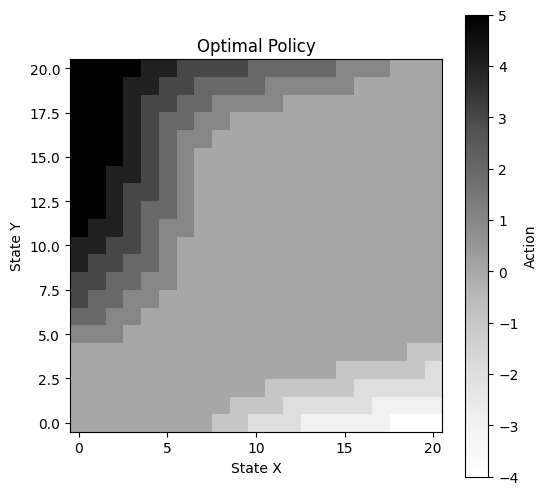

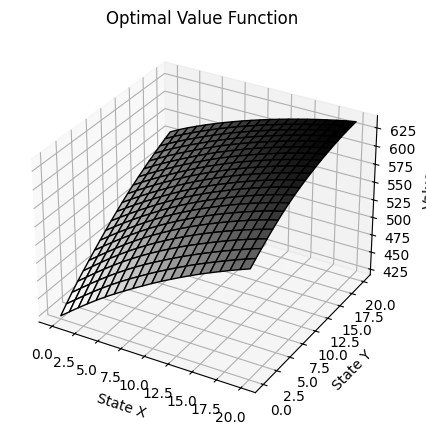

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Sample 21x21 states
policy_sample = policy[:21, :21]
V_sample = V[:21, :21]

# --- Plot Optimal Policy (2D, black and white) ---
plt.figure(figsize=(6,6))
plt.imshow(policy_sample, cmap='Greys', interpolation='nearest', origin='lower')
plt.colorbar(label='Action')
plt.title('Optimal Policy')
plt.xlabel('State X')
plt.ylabel('State Y')
plt.show()

# --- Plot Optimal Value Function (3D, black and white) ---
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')
X, Y = np.meshgrid(np.arange(V_sample.shape[1]), np.arange(V_sample.shape[0]))
ax.plot_surface(X, Y, V_sample, cmap='Greys', edgecolor='k')
ax.set_title('Optimal Value Function')
ax.set_xlabel('State X')
ax.set_ylabel('State Y')
ax.set_zlabel('Value')
plt.show()